![Текст ссылки](https://media.licdn.com/dms/image/v2/D5612AQEwbWIy3jsIXg/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1662527651491?e=2147483647&v=beta&t=7z5zDebOUpmbrxwYRoMxWu3P46GnMgr8un3kc_O4z7E)

#**Практика №1**




### 📝 Самостоятельные задания

#### Задание 1. Анализ выбросов
Постройте **ящики с усами (boxplots)** для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида *Iris virginica* по признаку `sepal width`. Какой процент наблюдений выходит за границы усов?

<details>
<summary>💡 Подсказка</summary>
Используйте `sns.boxplot(x='species', y='sepal width (cm)', data=df)`. Границы усов = Q1 - 1.5×IQR и Q3 + 1.5×IQR.
</details>

#### Задание 2. Сравнение дисперсий
Рассчитайте **коэффициент вариации** (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

<details>
<summary>💡 Подсказка</summary>
`cv = (df[col].std() / df[col].mean()) * 100`. Высокий CV (>30%) указывает на сильную изменчивость — такие признаки часто требуют масштабирования.
</details>

#### Задание 3. Создание нового признака
Создайте производный признак **«соотношение длины и ширины лепестка»** (`petal_length / petal_width`). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?

<details>
<summary>💡 Подсказка</summary>
`df['petal_ratio'] = df['petal length (cm)'] / df['petal width (cm)']`. Используйте `sns.violinplot` для сравнения распределений.
</details>



# РЕШЕНИЕ ЗАДАЧИ №1

##

## Задание 1. Анализ выбросов
Постройте ящики с усами (boxplots) для каждого признака с разбивкой по видам. Определите, есть ли выбросы у вида Iris virginica по признаку sepal width. Какой процент наблюдений выходит за границы усов?

Датасет Iris загружен.

Информация о типах данных и пропусках
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


 Быстрый просмотр первых 7 строк 
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
5           5.4          3.9           1.7          0.4 

ValueError: Invalid affine transformation matrix

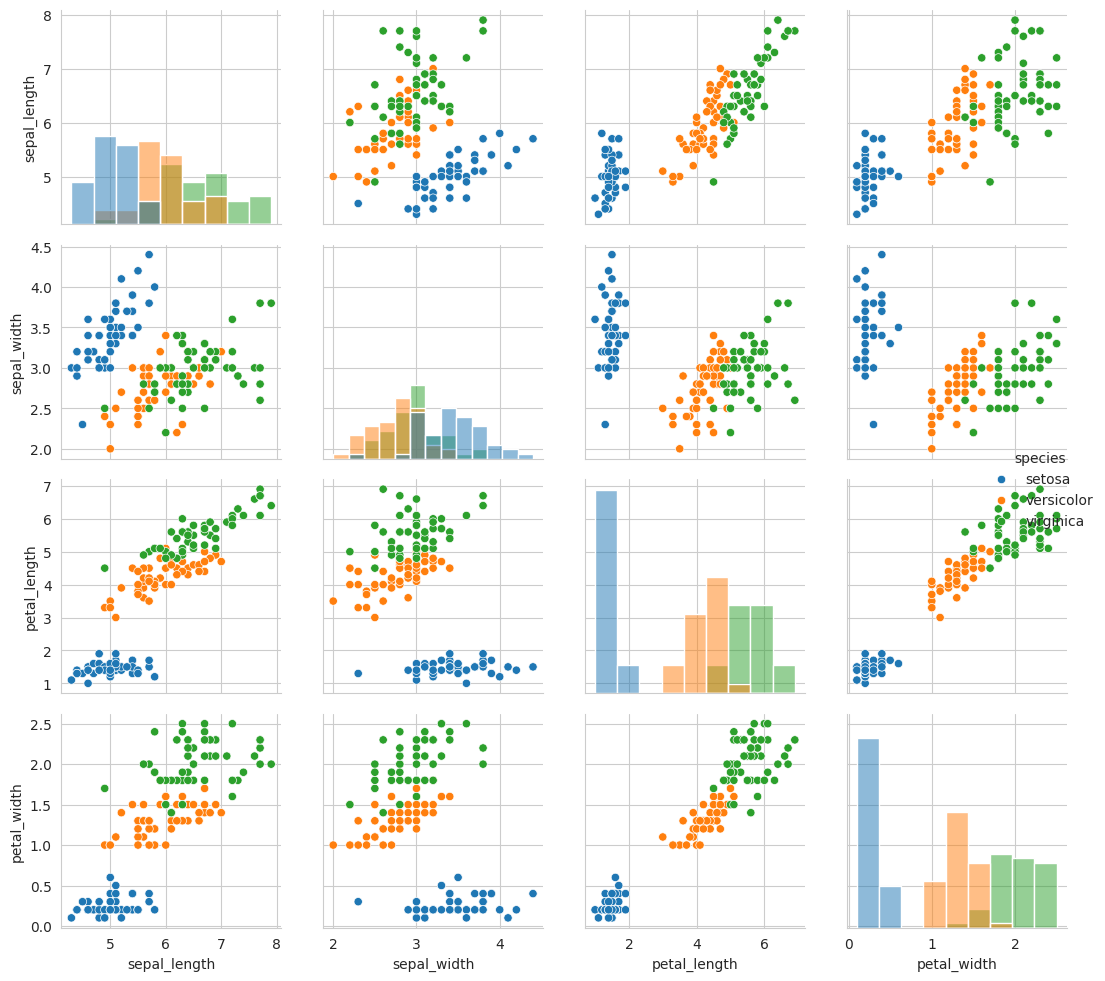

In [15]:
# Установка значения генератора случайных чисел
import numpy as np
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Импортируем основные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установка значения генератора случайных чисел
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загружаем датасет через seaborn
df = sns.load_dataset('iris')
print("Датасет Iris загружен.\n")

# Информация о типах данных и пропусках
print( "Информация о типах данных и пропусках" )
print(df.info())
print("\n")

# Быстрый просмотр первых 7 строк
print( " Быстрый просмотр первых 7 строк " )
print(df.head(7))
print("\n")

# Разделение данных на X (признаки) и y (целевая переменная)
# Источник: Scikit-learn developers. (2023). "An introduction to machine learning with scikit-learn".
#          https://scikit-learn.org/stable/tutorial/basic/tutorial.html
print("\n" + "="*50)
print(" Разделение на X и Y ")
X = df.drop(['species'], axis=1).values  # удаляем только species, target нет в Iris
y = df['species'].values
print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер вектора меток y: {y.shape}")
print(f"Первые 5 строк X:\n{X[:7]}")
print(f"Первые 5 значений y: {y[:7]}")

# Статистика распределения: среднее, СКО, квартили
print( " Статистика распределения " )
print(df.describe())
print("\n")

# Визуализация: парные графики (pairplot) для общего понимания
sns.pairplot(df, hue='species', diag_kind='hist')
plt.suptitle('Парные графики признаков Iris', y=1.02)
plt.show()

# Настройка стиля графиков (Белый фон с серыми линиями сетки)
# Источник: Seaborn documentation. "Controlling figure aesthetics"
# Matplotlib documentation. "Customizing Matplotlib with style sheets and rcParams"
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)  # Размер: 10x6 дюймов


# Задание 1: Анализ выбросов с помощью ящиков с усами (boxplot)
print("\n" + "="*50)
print("\n" + "Задание 1: Анализ выбросов с помощью ящиков с усами (boxplot)")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))                                # Создаем 4 графика (2 ряда по 2 графика)
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']       # Список признаков для анализа
for i, ax in enumerate(axes.flat):                                              # Строим boxplot для каждого признака
    sns.boxplot(x='species', y=features[i], data=df, ax=ax)               # x='species' - группировка по видам, y=features[i] - текущий признак
    ax.set_title(f'Распределение {features[i]} по видам')                       # Заголовок графика
plt.tight_layout()
plt.show()

# 2. Детальный анализ для вида Iris virginica по признаку sepal_width
# Источник: McGill, R., Tukey, J. W., & Larsen, W. A. (1978). Variations of box plots.
print("\n" + "="*50)
print( " Анализ выбросов для Iris virginica (sepal_width) " )

# Отбираем только данные вида virginica и только столбец sepal_width
virginica_data = df[df['species'] == 'virginica']['sepal_width']

# Расчет границ усов по формуле из задания
Q1 = virginica_data.quantile(0.25)                                              # Q1 - первый квартиль (25% данных меньше этого значения)
Q3 = virginica_data.quantile(0.75)                                              # Q3 - третий квартиль (75% данных меньше этого значения)
IQR = Q3 - Q1                                                                   # IQR - межквартильный размах (размах средних 50% данных)
# Границы усов (whiskers) по формуле из задания:
lower_bound = Q1 - 1.5 * IQR                                                    # Нижняя граница = Q1 - 1.5 × IQR
upper_bound = Q3 + 1.5 * IQR                                                    # Верхняя граница = Q3 + 1.5 × IQR

# Находим выбросы - значения за границами усов
outliers = virginica_data[(virginica_data < lower_bound) | (virginica_data > upper_bound)]

# Выводим результаты
print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Границы усов: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Всего наблюдений virginica: {len(virginica_data)}")
print(f"Количество выбросов: {len(outliers)}")

# Считаем процент выбросов, если они есть
if len(outliers) > 0:
    percentage = (len(outliers) / len(virginica_data)) * 100
    print(f"Процент выбросов: {percentage:.1f}%")
else:
    print("Выбросы отсутствуют (0%)")




## Вывод
У вида Iris virginica по признаку sepal width наблюдается три выброса, а шесть процентов наблюдений выходит за границы усов. Значения за границами усов [2.237, 3.738]


## Задание 2. Сравнение дисперсий
Рассчитайте коэффициент вариации (стандартное отклонение / среднее × 100%) для каждого признака. Какой признак наиболее изменчив относительно своего среднего значения? Почему это важно для нормализации данных?

In [ ]:
# Импортируем основные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установка значения генератора случайных чисел
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загружаем датасет через seaborn
df = sns.load_dataset('iris')
print("Датасет Iris загружен.\n")

print(" Разделение на X и Y ")
X = df.drop(['species'], axis=1).values  # удаляем только species, target нет в Iris
y = df['species'].values
print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер вектора меток y: {y.shape}")
print(f"Первые 5 строк X:\n{X[:7]}")
print(f"Первые 5 значений y: {y[:7]}")


# Настройка стиля графиков (Белый фон с серыми линиями сетки)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)  # Размер: 10x6 дюймов

#  Задание 2: Коэффициент вариации (CV)
# Источник: Everitt, B. S., & Skrondal, A. (2010). "The Cambridge Dictionary of Statistics"
print("\n" + "="*150)
print("Коэффициент вариации (CV)")

# Выбираем только числовые признаки
numeric_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Словарь для хранения результатов
cv_results = {}

# Расчет CV для каждого признака по формуле: (std / mean) * 100%
for col in numeric_cols:
    mean_val = df[col].mean()        # Среднее значение
    std_val = df[col].std()          # Стандартное отклонение
    cv = (std_val / mean_val) * 100  # Коэффициент вариации в процентах
    cv_results[col] = round(cv, 2)   # Сохраняем с округлением до 2 знаков

    # Определяем уровень изменчивости
    if cv > 30:
        level = "Высокий (>30%)"
    elif cv > 15:
        level = "Средний (15-30%)"
    else:
        level = "Низкий (<15%)"

    print(f"{col}: {cv:.2f}% - {level}")

# Находим признак с максимальным CV
most_variable = max(cv_results, key=cv_results.get)
print(f"\n Наиболее изменчивый признак: {most_variable} ({cv_results[most_variable]}%)")

# Визуализация
# Источник: Hunter, J. D. (2007). "Matplotlib: A 2D graphics environment".
# Создание нового окна для графика
plt.figure(figsize=(8, 5))

# Создание списка цветов для каждого столбца гистограммы
colors = ['red' if cv > 30 else 'orange' if cv > 15 else 'green' for cv in cv_results.values()]  # Для каждого значения cv (коэффициента вариации) из cv_results.values():
plt.bar(cv_results.keys(), cv_results.values(), color=colors, alpha=0.7)                         # Построение столбчатой диаграммы (bar chart)
plt.axhline(y=30, color='red', linestyle='--', label='Порог высокой изменчивости (30%)')         # Добавление горизонтальной линии на уровне y=30 (порог высокой изменчивости)
plt.axhline(y=15, color='orange', linestyle='--', label='Порог умеренной изменчивости (15%)')    # Добавление горизонтальной линии на уровне y=15 (порог умеренной изменчивости)
plt.title('Коэффициент вариации признаков Iris')                                                 # Установка заголовка графика
plt.ylabel('CV (%)')                                                                             # Установка подписи для оси Y (вертикальной)
plt.xticks(rotation=15)                                                                          # Поворот подписей на оси X на 15 градусов
plt.legend()                                                                                     # Отображение легенды (подписей к линиям)
plt.tight_layout()
plt.show()

## Вывод
Коэффициент вариации:
sepal_length(длина чашелистика): 14.17%
sepal_width (ширина чашелистика): 14.26%
petal_length (длина лепестка): 46.97%  
petal_width (ширина лепестка): 63.56%
Наиболее изменчивый признак  относительно своего среднего значения является petal_width (ширина лепестка) с коэффициентом вариации 63.56%.
Признаки с высоким коэффициентом вариации (petal_width, petal_length) имеют большой разброс значений.
Нормализация нужна, чтобы все признаки были в равных условиях.

## Задание 3. Создание нового признака
Создайте производный признак «соотношение длины и ширины лепестка» (petal_length / petal_width). Постройте гистограмму этого признака по видам. Улучшает ли он разделение классов по сравнению с исходными признаками?

In [ ]:
# Импортируем основные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установка значения генератора случайных чисел
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загружаем датасет через seaborn
df = sns.load_dataset('iris')
print("Датасет Iris загружен.\n")

print(" Разделение на X и Y ")
X = df.drop(['species'], axis=1).values  # удаляем только species, target нет в Iris
y = df['species'].values
print(f"Размер матрицы признаков X: {X.shape}")
print(f"Размер вектора меток y: {y.shape}")
print(f"Первые 5 строк X:\n{X[:7]}")
print(f"Первые 5 значений y: {y[:7]}")


#Задание 3: Производный признак
print("\n" + "="*150)
print("Задание 3: Производный признак")

# Создаем признак "соотношение длины лепестка к ширине"
df['petal_ratio'] = df['petal_length'] / df['petal_width']
print("Новый признак 'petal_ratio' создан.")
print(df[['species', 'petal_length', 'petal_width', 'petal_ratio']].head(10))

# Гистограмма производного признака "соотношение длины и ширины лепестка"
plt.figure(figsize=(10, 6))

# Строим гистограмму с наложением распределений по видам с помощью Seaborn
sns.histplot(data=df, x='petal_ratio', hue='species', kde=True, bins=20, alpha=0.7)
plt.title('Распределение признака petal_ratio (длина/ширина лепестка) по видам ирисов') # Добавляем заголовок графика
plt.xlabel('petal_length / petal_width')       # Подписываем ось X (горизонтальную)
plt.ylabel('Частота')                          # Подписываем ось Y (вертикальную)
plt.legend(title='Вид ириса')                  # Добавляем легенду с заголовком 'Вид'
plt.grid(axis='y', linestyle='--', alpha=0.3)  # Добавляем сетку на график
plt.show()                                     # Отображаем график на экране

# Для сравнения с исходными признаками - создадим сетку из 4 графиков
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Список признаков для сравнения (3 исходных + 1 новый)
features_to_plot = ['petal_length', 'petal_width', 'sepal_length', 'petal_ratio']
titles = ['Длина лепестка (petal_length)',
          'Ширина лепестка (petal_width)',
          'Длина чашелистика (sepal_length)',
          'Соотношение длина/ширина лепестка (petal_ratio)']

# Строим гистограммы для каждого признака
for idx, (feature, title) in enumerate(zip(features_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]                                       # Выбираем нужную позицию для графика в сетке 2x2
    sns.histplot(data=df, x=feature, hue='species', kde=True, ax=ax, bins=15, alpha=0.7) # Строим гистограмму на выбранных осях (ax)
    ax.set_title(title)                                                # Устанавливаем заголовок для текущего подграфика
    ax.set_xlabel(feature)                                             # Подписываем ось X - название признака
    ax.set_ylabel('Частота')                                           # Подписываем ось Y - частота (количество наблюдений)
    ax.grid(axis='y', linestyle='--', alpha=0.3)                       # Добавляем сетку только по оси Y
plt.tight_layout()
plt.show()

# Количественная оценка разделения
print("\n" + "="*60)
print("КОЛИЧЕСТВЕННАЯ ОЦЕНКА РАЗДЕЛЕНИЯ КЛАССОВ")
print("="*60)

# Функция для расчета коэффициента разделения между двумя классами
# Источник: Fisher, R. A. (1936). "The use of multiple measurements in taxonomic problems". Annals of Eugenics, 7(2), 179-188.
# Функция для расчета коэффициента разделения между двумя классами
def separation_score(df, feature, class1, class2):
    # Данные для каждого класса
    data1 = df[df['species'] == class1][feature]
    data2 = df[df['species'] == class2][feature]

    # Средние и стандартные отклонения
    mean1, mean2 = data1.mean(), data2.mean()
    std1, std2 = data1.std(), data2.std()

    # Формула: |разница средних| / (сумма стандартных отклонений)
    separation = abs(mean1 - mean2) / (std1 + std2)
    return separation

# Сравниваем все признаки
features_to_compare = ['petal_length', 'petal_width', 'sepal_length', 'sepal_width', 'petal_ratio']
classes = [('setosa', 'versicolor'), ('setosa', 'virginica'), ('versicolor', 'virginica')]

# Создаем таблицу результатов
results = []                                                  # Создаем пустой список для хранения результатов
for feature in features_to_compare:                           # Внешний цикл: проходим по всем признакам из списка features_to_compare
    row = {'Признак': feature}                                # Создаем новый словарь (строку таблицы) с названием признака
    for class1, class2 in classes:                            # Внутренний цикл: проходим по всем парам классов для сравнения
        score = separation_score(df, feature, class1, class2) # Вычисляем коэффициент разделения между двумя классами для текущего признака
        row[f'{class1}-{class2}'] = round(score, 3)           # Добавляем в словарь новую пару ключ-значение, Значение: округленный до 3 знаков коэффициент разделения
    results.append(row)                                       # Добавляем заполненный словарь в список результатов

# Выводим результаты
results_df = pd.DataFrame(results)                            # Преобразуем список словарей в DataFrame (таблицу)
print("\nКоэффициент разделения (чем выше, тем лучше):")      # to_string(index=False) - выводим таблицу без индексов (без номеров строк)
print(results_df.to_string(index=False))

# Находим лучший признак
print("\n" + "="*60)
avg_scores = {}                                              # Создаем пустой словарь для хранения средних коэффициентов по каждому признаку
for feature in features_to_compare:                          # Проходим по всем признакам
    avg = 0                                                  # Инициализируем сумму коэффициентов для текущего признака
    for class1, class2 in classes:                            # Проходим по всем трем парам классов
        avg += separation_score(df, feature, class1, class2)
    avg_scores[feature] = round(avg / 3, 3)                   # Вычисляем среднее арифметическое (делим сумму на количество пар = 3)

best_feature = max(avg_scores, key=avg_scores.get)            # Находим признак с максимальным средним коэффициентом разделения
print(f"Лучший признак по среднему коэффициенту разделения: {best_feature} ({avg_scores[best_feature]})")

# Сравнение с исходными признаками
print("\nСредние коэффициенты разделения:")
for feature, score in avg_scores.items():                      # Проходим по всем признакам и их средним значениям
    print(f"  {feature}: {score}")

if best_feature == 'petal_ratio':
    print("\n Новый признак УЛУЧШАЕТ разделение классов!")
else:
    print(f"\n Новый признак занимает {list(avg_scores.keys()).index('petal_ratio') + 1} место по качеству разделения")

## Вывод
Новый признак petal_ratio не улучшает разделение классов, так как он занимает 4 место по коэффициенту разделения (1,022) противопостовляясь petal_length с коэффициентом (3.75)


### 📝 Самостоятельные задания (часть 2)

#### Задание 1. Выявление мультиколлинеарности
Найдите **все пары признаков** с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: `Признак_1`, `Признак_2`, `Корреляция`. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

<details>
<summary>💡 Подсказка</summary>
Используйте метод `.corr()` для получения матрицы корреляций, затем примените маску `abs(corr) > 0.7`. Для подсчёта пар используйте `np.where()` или итерацию по треугольной матрице.
</details>

#### Задание 2. Анализ асимметрии распределений
Рассчитайте **коэффициент асимметрии (skewness)** для каждого признака с помощью `scipy.stats.skew()`. Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

<details>
<summary>💡 Подсказка</summary>
Положительная асимметрия означает, что большинство значений сосредоточено слева с длинным правым хвостом. Такие признаки часто требуют логарифмического преобразования перед обучением модели.
</details>

#### Задание 3. Создание «идеального» разделяющего признака
Сконструируйте новый признак как **линейную комбинацию** двух существующих:  
`wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']`  
Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт **коэффициента разделения классов** (разница средних / сумма стандартных отклонений).

<details>
<summary>💡 Подсказка</summary>
Для количественной оценки используйте:  
`separation = abs(mean_class1 - mean_class2) / (std_class1 + std_class2)`  
Чем выше значение, тем лучше разделение.
</details>

# РЕШЕНИЕ ЗАДАЧИ №2

## Задание 1. Выявление мультиколлинеарности
Найдите все пары признаков с абсолютной корреляцией |r| > 0.7. Создайте таблицу из 3 столбцов: Признак_1, Признак_2, Корреляция. Сколько таких пар существует? Какой признак участвует в наибольшем числе сильных корреляций?

✓ Данные загружены. Форма: (178, 15)

Первые 3 строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1


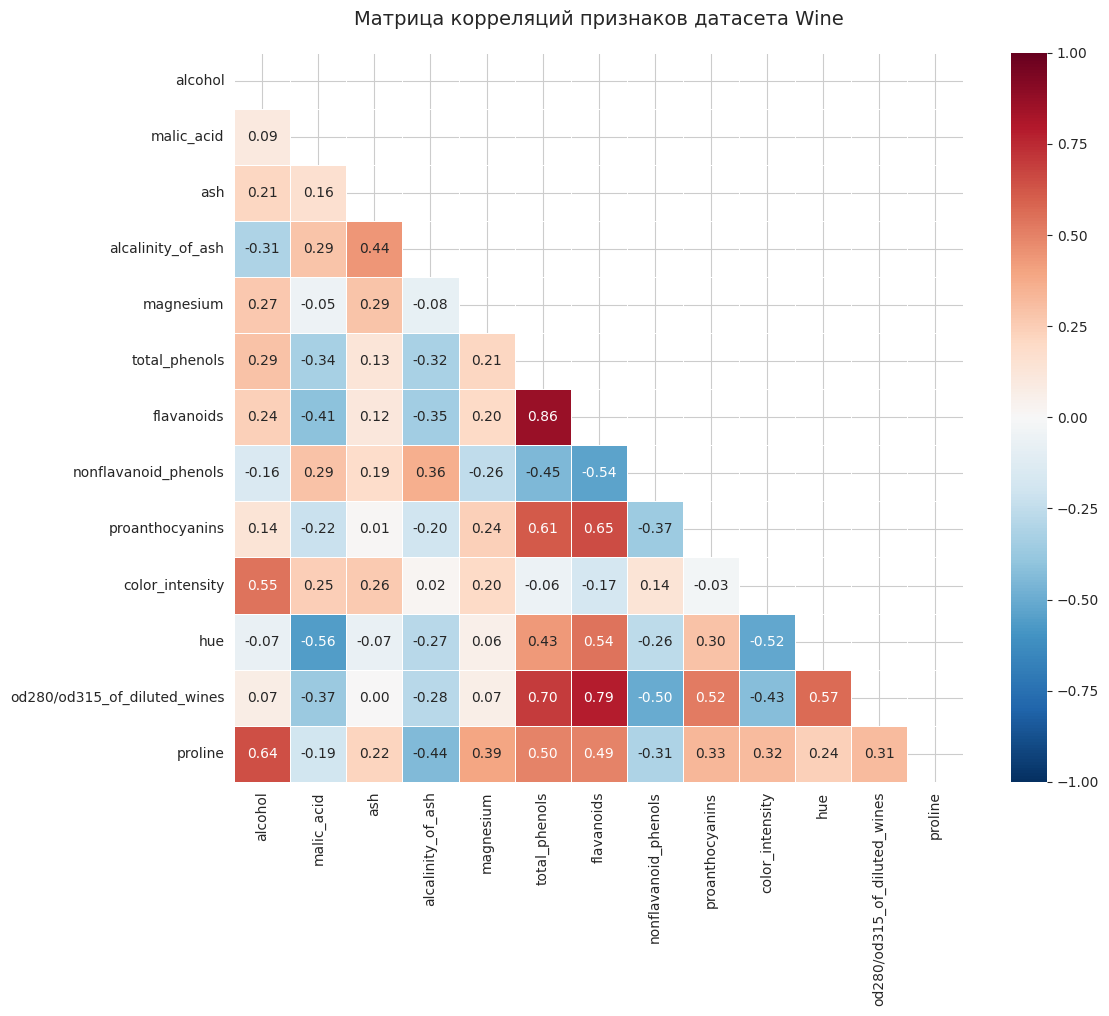


Задание: Выявление пар с сильной корреляцией (|r| > 0.7)

ПАРЫ ПРИЗНАКОВ С |r| > 0.7
    Признак_1                    Признак_2  Корреляция
total_phenols                   flavanoids       0.865
   flavanoids od280/od315_of_diluted_wines       0.787

КОЛИЧЕСТВЕННЫЙ АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ
1. Количество пар с |r| > 0.7: 2
2. Признак с наибольшим числом сильных корреляций: flavanoids
   Участвует в 2 парах

   Участие всех признаков в сильных корреляциях:
   • flavanoids: 2 связей
   • total_phenols: 1 связей
   • od280/od315_of_diluted_wines: 1 связей


In [8]:
# Импортируем основные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_wine

# Установка значения генератора случайных чисел
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загрузка датасета Wine
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])
print("✓ Данные загружены. Форма:", df.shape)
print("\nПервые 3 строки:")
display(df.head(3))

# Тепловая карта корреляций (только для признаков)
plt.figure(figsize=(12, 10))
corr_matrix = df.iloc[:, :-2].corr()                                             # Исключаем target и region
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))                            # Скрываем верхний треугольник
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Матрица корреляций признаков датасета Wine', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# ================================================================================================================================================================
# Задание: Выявление пар с сильной корреляцией (|r| > 0.7)
# Источник: Kuhn, M., & Johnson, K. (2019). "Feature Engineering and Selection: A Practical Approach for Predictive Models". Chapman and Hall/CRC.
print("\n" + "="*150)
print("Задание: Выявление пар с сильной корреляцией (|r| > 0.7)")
threshold = 0.7                     # Задаем порог для определения сильной корреляции
features = wine.feature_names       # Список названий признаков
high_corr_pairs = []                # Пустой список для хранения найденных пар

# Проходим по верхнему треугольнику матрицы (i < j), чтобы не дублировать пары
for i in range(len(features)):                    # i - индекс первого признака
    for j in range(i+1, len(features)):           # j - индекс второго признака (всегда больше i)
        corr_value = corr_matrix.iloc[i, j]       # Получаем корреляцию между i-м и j-м признаком
        if abs(corr_value) > threshold:           # Проверяем, превышает ли абсолютное значение порог
            high_corr_pairs.append({               # Добавляем словарь с информацией о паре в список
                'Признак_1': features[i],          # Название первого признака
                'Признак_2': features[j],          # Название второго признака
                'Корреляция': round(corr_value, 3) # Значение корреляции
            })

# Создаем таблицу результатов
corr_table = pd.DataFrame(high_corr_pairs)         # pd.DataFrame() преобразует список словарей в таблицу
print("\n" + "="*60)
print("ПАРЫ ПРИЗНАКОВ С |r| > 0.7")
print("="*60)
if len(corr_table) > 0:                             # .to_string(index=False) выводит таблицу без индексов (без номеров строк)
    print(corr_table.to_string(index=False))
else:
    print("Сильная корреляция не обнаружена.")

#  ПОДСЧЕТ КОЛИЧЕСТВА ПАР И ПОИСК ПРИЗНАКА-ЛИДЕРА
print("\n" + "="*150)
print("КОЛИЧЕСТВЕННЫЙ АНАЛИЗ МУЛЬТИКОЛЛИНЕАРНОСТИ")
print("="*150)
num_pairs = len(corr_table)                                   # len() возвращает количество строк в DataFrame
print(f"1. Количество пар с |r| > {threshold}: {num_pairs}")

# Какой признак участвует в наибольшем числе сильных корреляций?
if num_pairs > 0:                                              # Создаем словарь для подсчета участия каждого признака
    participation = {feature: 0 for feature in features}

    # Проходим по каждой найденной паре
    for _, row in corr_table.iterrows():
        participation[row['Признак_1']] += 1 # Увеличиваем счетчик для первого признака в паре
        participation[row['Признак_2']] += 1 # Увеличиваем счетчик для второго признака в паре

    # Находим признак с максимальным значением счетчика
    max_feature = max(participation, key=participation.get)
    max_count = participation[max_feature]

    print(f"2. Признак с наибольшим числом сильных корреляций: {max_feature}")
    print(f"   Участвует в {max_count} парах")

    # Дополнительно выводим участие всех признаков
    print("\n   Участие всех признаков в сильных корреляциях:")
    # Сортируем по убыванию участия (reverse=True)
    for feature, count in sorted(participation.items(), key=lambda x: x[1], reverse=True):
        if count > 0:  # Выводим только те, у которых есть связи
            print(f"   • {feature}: {count} связей")
else:
    print(" Нет признаков с сильными корреляциями.")



## Вывод:
Признаки с абсолютной корреляцией |r| > 0.7 являются две пары.
Существует две пары.
Признак flavanoids участвует в наибольшем числе сильных корреляций, так как у него две связи

## Задание 2. Анализ асимметрии распределений
Рассчитайте коэффициент асимметрии (skewness) для каждого признака с помощью scipy.stats.skew(). Какие 3 признака имеют наибольшую положительную асимметрию (правый хвост)? Почему это важно для применения алгоритмов, чувствительных к распределению (например, SVM с ядром RBF)?

✓ Данные загружены. Форма: (178, 15)

Первые 3 строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1


КОЭФФИЦИЕНТ АСИММЕТРИИ (SKEWNESS)
                     Признак  Коэффициент
                     alcohol       -0.051
                  malic_acid        1.040
                         ash       -0.177
           alcalinity_of_ash        0.213
                   magnesium        1.098
               total_phenols        0.087
                  flavanoids        0.025
        nonflavanoid_phenols        0.450
             proanthocyanins        0.517
             color_intensity        0.869
                         hue        0.021
od280/od315_of_diluted_wines       -0.307
                     proline        0.768

ПРИЗНАКИ С НАИБОЛЬШЕЙ ПОЛОЖИТЕЛЬНОЙ АСИММЕТРИЕЙ
        Признак  Коэффициент
      magnesium        1.098
     malic_acid        1.040
color_intensity        0.869


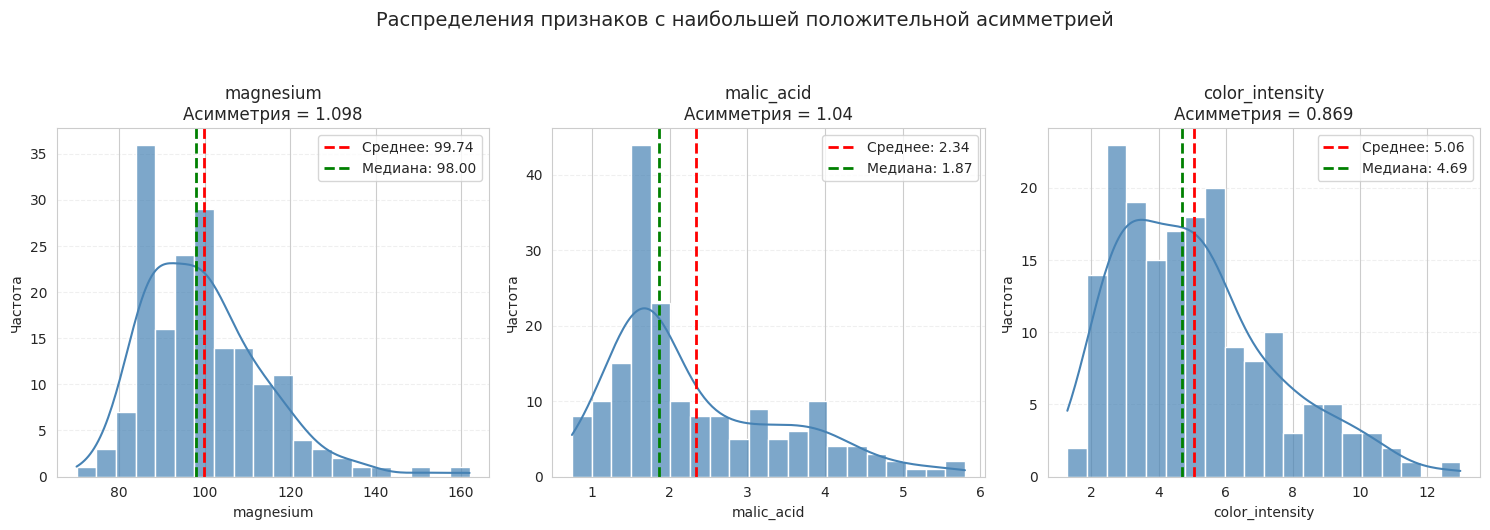

In [10]:
# Импортируем основные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_wine

# Установка значения генератора случайных чисел
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загрузка датасета Wine
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])
print("✓ Данные загружены. Форма:", df.shape)
print("\nПервые 3 строки:")
display(df.head(3))

# ====================================================================
# Задание: коэффициент асимметрии (skewness) для каждого признака
# Источник: Bulmer, M. G. (1979). "Principles of Statistics". Dover Publications.
# ====================================================================

print("="*150)
print("КОЭФФИЦИЕНТ АСИММЕТРИИ (SKEWNESS)")
print("="*150)
skewness_results = []
for col in wine.feature_names:
    # Рассчитываем коэффициент асимметрии
    skewness = df[col].skew()      # Формула: (1/n) * Σ((x - μ)/σ)³

    # Добавляем результат в список
    skewness_results.append({                 # Ключ 'Признак' - название признака, 'Коэффициент' - значение асимметрии
        'Признак': col,
        'Коэффициент': round(skewness, 3)     # Округляем до 3 знаков для читаемости
    })

# Создаем DataFrame с результатами
skewness_df = pd.DataFrame(skewness_results)
print(skewness_df.to_string(index=False))     # index=False - убираем номера строк

# ============================================================================================================================================================================================================
# Признаки с положительной асимметрией
top_3_positive = skewness_df[skewness_df['Коэффициент'] > 0].sort_values('Коэффициент', ascending=False).head(3) # .head(3) - берем первые 3 (топ-3)
print("\n" + "="*60)
print("ПРИЗНАКИ С НАИБОЛЬШЕЙ ПОЛОЖИТЕЛЬНОЙ АСИММЕТРИЕЙ")
print("="*60)
print(top_3_positive.to_string(index=False))

# ============================================================================================================================================================================================================
# Визуализация признаков
# Создаем фигуру с тремя графиками в ряд
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Проверяем, что top_3_positive не пустой
if len(top_3_positive) > 0:
# Для каждого из трех признаков строим гистограмму
    for idx, (_, row) in enumerate(top_3_positive.iterrows()):
        feature = row['Признак']           # Название признака
        skew_val = row['Коэффициент']       # Значение асимметрии
        ax = axes[idx]                      # Выбираем текущую позицию графика
        sns.histplot(data=df, x=feature, kde=True, ax=ax, bins=20, color='steelblue', alpha=0.7) # Гистограмма с сглаженной кривой плотности
# Добавляем линии среднего и медианы
        mean_val = df[feature].mean()        # Среднее значение
        median_val = df[feature].median()    # Медианное значение
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_val:.2f}')       # Красная линия - среднее (смещено в сторону хвоста)
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_val:.2f}') # Зеленая линия - медиана (устойчива к выбросам)

        # Настройки графика
        ax.set_title(f'{feature}\nАсимметрия = {skew_val}', fontsize=12)
        ax.set_xlabel(feature)
        ax.set_ylabel('Частота')
        ax.legend()
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Общий заголовок
    plt.suptitle('Распределения признаков с наибольшей положительной асимметрией', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Нет признаков с положительной асимметрией")



## Вывод
Признак  Коэффициент
 magnesium (магний) = 1.098 malic_acid (яблочная кислота) = 1.040
color_intensity (интенсивность цвета) = 0.869. Это важно так как алгоритмы чувствительны к маштабу, то есть большие значения перевешивают маленькии и для этого необходимо распределить их равномерно.

## Задание 3. Создание «идеального» разделяющего признака
Сконструируйте новый признак как линейную комбинацию двух существующих:
wine_quality_index = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']
Постройте график распределения этого индекса по регионам. Улучшает ли он разделение классов по сравнению с исходными признаками? Подтвердите вывод количественно через расчёт коэффициента разделения классов (разница средних / сумма стандартных отклонений).


✓ Данные загружены. Форма: (178, 15)

Первые 3 строки:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,region
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Region_1
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Region_1
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Region_1


Задание: Создание нового признака (линейная комбинация)
НОВЫЙ ПРИЗНАК СОЗДАН
Формула: wine_quality_index = 0.6*flavanoids + 0.4*color_intensity

Первые 10 строк с новым признаком:
 flavanoids  color_intensity  wine_quality_index  target
       3.06             5.64               4.092       0
       2.76             4.38               3.408       0
       3.24             5.68               4.216       0
       3.49             7.80               5.214       0
       2.69             4.32               3.342       0
       3.39             6.75               4.734       0
       2.52             5.25               3.612       0
       2.51             5.05               3.526       0
       2.98             5.20               3.868       0
       3.15             7.22               4.778       0


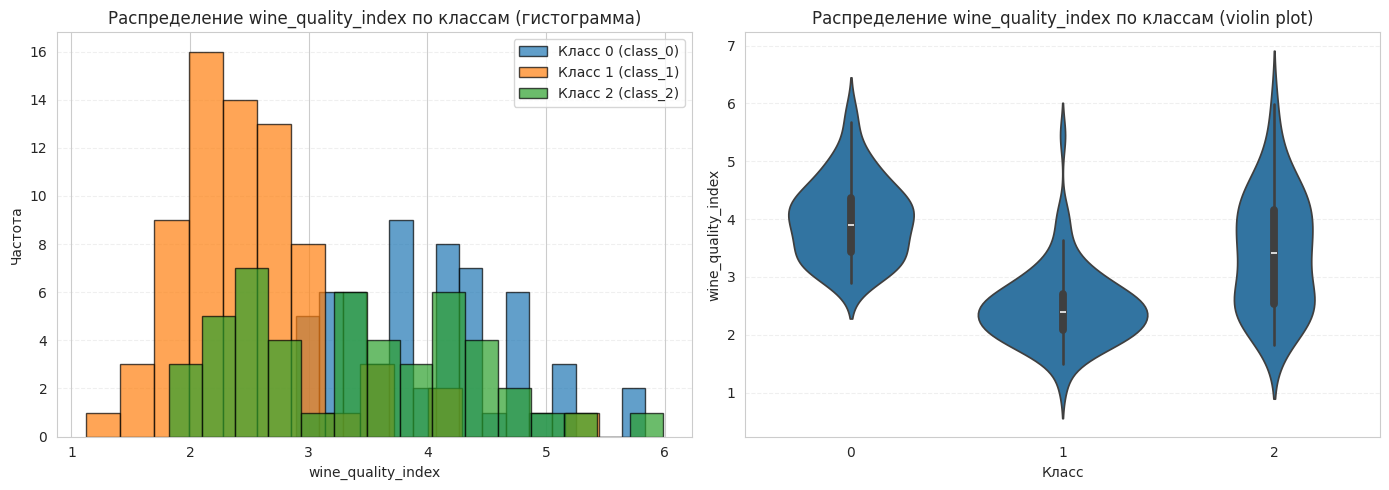


КОЭФФИЦИЕНТ РАЗДЕЛЕНИЯ
           Признак  Классы 0-1  Классы 0-2  Классы 1-2
        flavanoids       0.817       3.185       1.300
   color_intensity       1.129       0.526       1.332
wine_quality_index       1.124       0.339       0.568

СРЕДНИЙ КОЭФФИЦИЕНТ РАЗДЕЛЕНИЯ (ПО ВСЕМ ПАРАМ КЛАССОВ)
flavanoids: 1.768
color_intensity: 0.996
wine_quality_index: 0.677


In [14]:
# Импортируем основные библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.datasets import load_wine

# Установка значения генератора случайных чисел
np.random.seed(42)  # Гарантирует одинаковые результаты при повторных запусках

# Загрузка датасета Wine
wine = load_wine()
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['region'] = pd.Categorical.from_codes(wine.target, [f'Region_{i+1}' for i in range(3)])
print("✓ Данные загружены. Форма:", df.shape)
print("\nПервые 3 строки:")
display(df.head(3))

# ====================================================================
# Задание: Создание нового признака (линейная комбинация)
print("="*150)
print("Задание: Создание нового признака (линейная комбинация)")
print("="*150)

# Создаем новый признак по формуле из задания  0.6 * flavanoids + 0.4 * color_intensity
df['wine_quality_index'] = 0.6 * df['flavanoids'] + 0.4 * df['color_intensity']
print("НОВЫЙ ПРИЗНАК СОЗДАН")
print("Формула: wine_quality_index = 0.6*flavanoids + 0.4*color_intensity")
print("\nПервые 10 строк с новым признаком:")
print(df[['flavanoids', 'color_intensity', 'wine_quality_index', 'target']].head(10).to_string(index=False))

# ====================================================================
# Задание: Визуализация распределение
# Источник: Waskom, M. L. (2021). "seaborn: statistical data visualization".Journal of Open Source Software, 6(60), 3021.
# Создаем фигуру с двумя графиками
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Гистограмма с наложением по классам
ax1 = axes[0]
for target in sorted(df['target'].unique()):                   # Проходим по каждому уникальному классу (0, 1, 2)
    data = df[df['target'] == target]['wine_quality_index']    # Отбираем данные только для текущего класса и нужного признака
    ax1.hist(data, alpha=0.7, label=f'Класс {target} ({wine.target_names[target]})', bins=15, edgecolor='black') # Строим гистограмму для текущего класса
ax1.set_xlabel('wine_quality_index')                           # Подпись оси X
ax1.set_ylabel('Частота')                                      # Подпись оси Y
ax1.set_title('Распределение wine_quality_index по классам (гистограмма)')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# График 2: Violin plot
ax2 = axes[1]
sns.violinplot(x='target', y='wine_quality_index', data=df, ax=ax2)
ax2.set_xlabel('Класс')
ax2.set_ylabel('wine_quality_index')
ax2.set_title('Распределение wine_quality_index по классам (violin plot)')
ax2.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ====================================================================
# Задание: Количественная оценка
# Источник: Cohen, J. (1988). "Statistical Power Analysis for the Behavioral Sciences" (2nd ed.).
# Функция для расчета коэффициента разделения между двумя классами
def separation_score(df, feature, class1, class2):
    """
    Рассчитывает коэффициент разделения между двумя классами.

    Параметры:
    df - DataFrame с данными
    feature - название признака
    class1, class2 - номера классов для сравнения

    Возвращает:
    separation - коэффициент разделения
    """
    # Данные для каждого класса
    data1 = df[df['target'] == class1][feature]  # Фильтруем данные для первого класса
    data2 = df[df['target'] == class2][feature]  # Фильтруем данные для второго класса

    # Средние значения
    mean1, mean2 = data1.mean(), data2.mean()

    # Стандартные отклонения
    std1, std2 = data1.std(), data2.std()

    # Формула: |разница средних| / (сумма стандартных отклонений)
    separation = abs(mean1 - mean2) / (std1 + std2)
    return separation

# Признаки для сравнения
features_to_compare = ['flavanoids', 'color_intensity', 'wine_quality_index']
# Пары классов для сравнения (0-1, 0-2, 1-2)
class_pairs = [(0, 1), (0, 2), (1, 2)]

# Создаем таблицу результатов
print("\n" + "="*150)
print("КОЭФФИЦИЕНТ РАЗДЕЛЕНИЯ")
print("="*150)

results = []
for feature in features_to_compare:
    row = {'Признак': feature}                                 # Создаем словарь для текущей строки таблицы
    for class1, class2 in class_pairs:                         # Внутренний цикл: проходим по каждой паре классов
        score = separation_score(df, feature, class1, class2)  # Вычисляем коэффициент разделени
        row[f'Классы {class1}-{class2}'] = round(score, 3)     # Добавляем результат в словарь (округленный до 3 знаков)
    results.append(row)

# Выводим таблицу
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# ====================================================================
# Задание: Расчет среднего коэффициента
print("\n" + "="*150)
print("СРЕДНИЙ КОЭФФИЦИЕНТ РАЗДЕЛЕНИЯ (ПО ВСЕМ ПАРАМ КЛАССОВ)")
print("="*150)

avg_scores = {}                                                 # Словарь для хранения средних значений
for feature in features_to_compare:                             # Для каждого признака вычисляем средний коэффициент
    total = 0                                                   # Сумма коэффициентов
    for class1, class2 in class_pairs:                          # Суммируем коэффициенты по всем трем парам классов
        total += separation_score(df, feature, class1, class2)
    avg_scores[feature] = round(total / 3, 3)                   # Вычисляем среднее (делим на количество пар = 3)

# Выводим результаты
for feature, score in avg_scores.items():
    print(f"{feature}: {score}")



## Вывод
Лучший признак: flavanoids (коэффициент = 1.768)

Новый признак ухудшает разделение классов по сравнению с исходными признаками.

wine_quality_index (новый): 0.677  хуже исходных, так как высокие значения признаков сочетались с низкими. Следовательно они  разнонаправленные изменения скомпенсировали друг друга, и классы перестали различаться. Таким образом, простое объединение признаков не всегда улучшает разделение.